
# **PEC 1: Data Mining and Dimensionality Reduction Methods**

Throughout this practical session, we will see how to apply different techniques that we have seen in class, such as EDA, Data Wrangling, or techniques to reduce the dimensionality of the dataset. To do this, we will carry out the following steps:

1.  Loading a dataset
2.  Data analysis

    2.1 Basic statistical analysis
    
    2.2 Exploratory data analysis

For this, we will need the following libraries:

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import datasets
from sklearn import preprocessing
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import validation_curve

import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
seed = 100

%matplotlib inline

# **1. Loading the dataset**

First, you must load the "Boston house prices" dataset, which contains the value of houses in different areas of Boston depending on multiple factors.

For the exercises in this example activity, we will use "MEDV" as the response variable: the median value of houses in an area of Boston (in k$).


**FIRST STEP: WHAT TYPE OF DATA SOURCE DO WE HAVE?**


### **Exercise:**

Load the "boston house-prices dataset" and show:

*   the number and name of the attributes (variables that could be used to predict the "MEDV" response)
*   the number of rows in the dataset

**Hint:** If you use sklearn (`sklearn.datasets.load_boston`), explore the different 'keys' of the obtained object.

**Hint:** It may be useful to pass the data (attributes + response) to a pandas dataframe.




## Attribute Information:

1.  CRIM     per capita crime rate by town
2.  ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
3.  INDUS    proportion of non-retail business acres per town
4.  CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
5.  NOX      nitric oxides concentration (parts per 10 million)
6.  RM       average number of rooms per dwelling
7.  AGE      proportion of owner-occupied units built prior to 1940
8.  DIS      weighted distances to five Boston employment centres
9.  RAD      index of accessibility to radial highways
10. TAX      full-value property-tax rate per $10,000
11. PTRATIO  pupil-teacher ratio by town

12. B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
13. LSTAT    % lower status of the population
14. MEDV     Median value of owner-occupied homes in $1000's




**SECOND STEP: LET'S QUICKLY EXPLORE WHAT WE HAVE**

In [29]:
# HELP - SUGGESTION. INSTALL PACKAGE TO SEE WHAT'S THERE; USING, FOR EXAMPLE, THE PLOT FUNCTION OF THE DATAPREP.EDA MODULE OF THE DATAPREP PACKAGE # We put the ! to install a package
from dataprep.eda import plot # With from _____ import we install the X method of the Y package

# HELP - SUGGESTION. IN THE FIRST STEP, WHEN READING THE HousingData.csv DATASET, WE ASSIGNED IT TO THE DATAFRAME VARIABLE "boston"

boston = pd.read_csv('HousingData.csv') # We read the dataset and assign it to the variable boston
plot(boston).show_browser() # With plot from the DataPrep library we can get a report of our dataset

  0%|          | 0/908 [00:00<?, ?it/s]

In [30]:
boston

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [31]:
df = boston

In [ ]:
df.shape

# **Basic statistical analysis**

### **Exercise:**

Perform a basic statistical analysis:


*   **Categorical variables:**
    *   Calculate the frequency
    *   Make a bar graph
*   **Numerical variables:**
    *   Calculate basic descriptive statistics: mean, median, standard deviation, ...
    *   Make a histogram of the INDUS, AGE and MEDV variables

**Hint:** You can use the 'pandas' library and its 'describe' and 'value_counts' functions, as well as the 'bar' and 'hist' functions of matplotlib.

### Check for null data

In [32]:
for columna in df.columns:
    print(f"Columna: {columna}, Tipo de dato: {df[columna].dtype}, Numero de valores nulos: {df[columna].isna().sum()}")

Columna: CRIM, Tipo de dato: float64, Numero de valores nulos: 20
Columna: ZN, Tipo de dato: float64, Numero de valores nulos: 20
Columna: INDUS, Tipo de dato: float64, Numero de valores nulos: 20
Columna: CHAS, Tipo de dato: float64, Numero de valores nulos: 20
Columna: NOX, Tipo de dato: float64, Numero de valores nulos: 0
Columna: RM, Tipo de dato: float64, Numero de valores nulos: 0
Columna: AGE, Tipo de dato: float64, Numero de valores nulos: 20
Columna: DIS, Tipo de dato: float64, Numero de valores nulos: 0
Columna: RAD, Tipo de dato: int64, Numero de valores nulos: 0
Columna: TAX, Tipo de dato: int64, Numero de valores nulos: 0
Columna: PTRATIO, Tipo de dato: float64, Numero de valores nulos: 0
Columna: B, Tipo de dato: float64, Numero de valores nulos: 0
Columna: LSTAT, Tipo de dato: float64, Numero de valores nulos: 20
Columna: MEDV, Tipo de dato: float64, Numero de valores nulos: 0


In [33]:
df['CRIM'].fillna(df['CRIM'].mean(), inplace=True)
df['ZN'].fillna(df['ZN'].mean(), inplace=True)
df['INDUS'].fillna(df['INDUS'].mean(), inplace=True)
df = df.dropna(subset=['CHAS'])
df['AGE'].fillna(df['AGE'].mean(), inplace=True)
df['LSTAT'].fillna(df['LSTAT'].mean(), inplace=True)

C:\Users\Eva Sánchez\AppData\Local\Temp\ipykernel_17568\3744441218.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AGE'].fillna(df['AGE'].mean(), inplace=True)
C:\Users\Eva Sánchez\AppData\Local\Temp\ipykernel_17568\3744441218.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['LSTAT'].fillna(df['LSTAT'].mean(), inplace=True)


In [37]:
for columna in df.columns:
    print(f"Columna: {columna}, Tipo de dato: {df[columna].dtype}, Numero de valores nulos: {df[columna].isna().sum()}")

Columna: CRIM, Tipo de dato: float64, Numero de valores nulos: 0
Columna: ZN, Tipo de dato: float64, Numero de valores nulos: 0
Columna: INDUS, Tipo de dato: float64, Numero de valores nulos: 0
Columna: CHAS, Tipo de dato: float64, Numero de valores nulos: 0
Columna: NOX, Tipo de dato: float64, Numero de valores nulos: 0
Columna: RM, Tipo de dato: float64, Numero de valores nulos: 0
Columna: AGE, Tipo de dato: float64, Numero de valores nulos: 0
Columna: DIS, Tipo de dato: float64, Numero de valores nulos: 0
Columna: RAD, Tipo de dato: int64, Numero de valores nulos: 0
Columna: TAX, Tipo de dato: int64, Numero de valores nulos: 0
Columna: PTRATIO, Tipo de dato: float64, Numero de valores nulos: 0
Columna: B, Tipo de dato: float64, Numero de valores nulos: 0
Columna: LSTAT, Tipo de dato: float64, Numero de valores nulos: 0
Columna: MEDV, Tipo de dato: float64, Numero de valores nulos: 0


### Categorical variables

0.0    452
1.0     34
Name: CHAS, dtype: int64


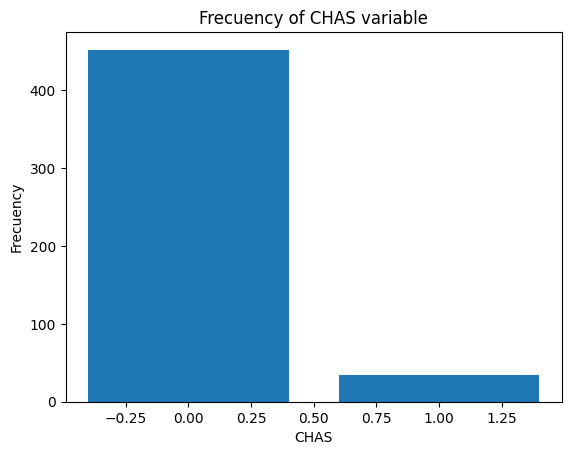

In [34]:
conteos = df['CHAS'].value_counts()

# Asegurarse de que el índice sea 0 y 1
eje_x = conteos.index
eje_y = df['CHAS'].value_counts()

plt.bar(eje_x, eje_y)
plt.xlabel('CHAS')
plt.ylabel('Frecuency')
plt.title('Frecuency of CHAS variable')

print(conteos)

### Numerical variables

Text(0, 0.5, 'Frequency')

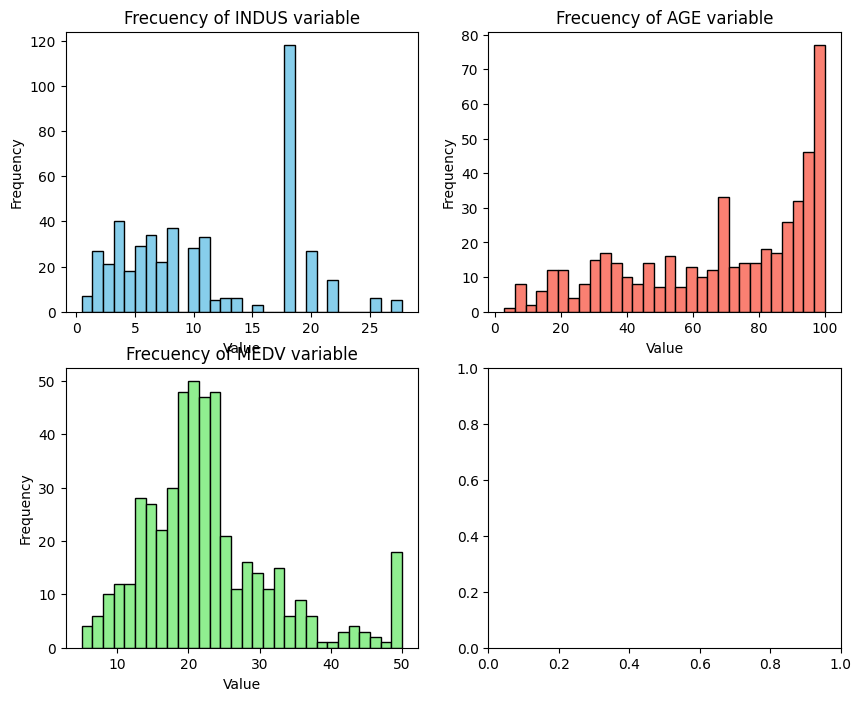

In [39]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# --- Gráfico 1 (Fila 0, Columna 0) ---
axs[0, 0].hist(df['INDUS'], bins=30, color='skyblue', edgecolor='black')
axs[0, 0].set_title('Frecuency of INDUS variable')
axs[0, 0].set_xlabel("Value")
axs[0, 0].set_ylabel("Frequency")

# --- Gráfico 2 (Fila 0, Columna 1) ---
axs[0, 1].hist(df['AGE'], bins=30, color='salmon', edgecolor='black')
axs[0, 1].set_title('Frecuency of AGE variable')
axs[0, 1].set_xlabel("Value")
axs[0, 1].set_ylabel("Frequency")

# --- Gráfico 3 (Fila 1, Columna 0) ---
axs[1, 0].hist(df['MEDV'], bins=30, color='lightgreen', edgecolor='black')
axs[1, 0].set_title('Frecuency of MEDV variable')
axs[1, 0].set_xlabel("Value")
axs[1, 0].set_ylabel("Frequency")

In [36]:
columna = []
media = []
mediana = []
desviacion_estandar = []
moda = []


for columna in df.columns:
    media.append(df[columna].mean())
    mediana.append(df[columna].median())
    desviacion_estandar.append(df[columna].std())
    moda.append(df[columna].mode()[0])

estadisticas = pd.DataFrame({'Columna': df.columns, 'Media': media, 'Mediana': mediana, 'Desviacion_Estandar': desviacion_estandar, 'Moda': moda})
estadisticas

,Columna,Media,Mediana,Desviacion_Estandar,Moda
0,CRIM,3.562090,0.289575,8.634572,3.611874
1,ZN,11.350285,0.000000,23.073829,0.000000
2,INDUS,10.989827,9.795000,6.734251,18.100000
3,CHAS,0.069959,0.000000,0.255340,0.000000
4,NOX,0.553699,0.538000,0.115390,0.538000
5,RM,6.296835,6.209000,0.699175,5.713000
6,AGE,68.353863,74.350000,27.504857,100.000000
7,DIS,3.788976,3.207450,2.096304,3.495200
8,RAD,9.395062,5.000000,8.626756,24.000000
9,TAX,405.485597,330.000000,167.604833,666.000000


# **Analysis:**

Comment on the results.



# **Exploratory data analysis**

In this exercise, we will explore the relationship of the attributes with the response variable, through graphs and analyzing the correlations of the numerical attributes.

In [14]:
response = "MEDV"
cat_feat = "CHAS"
num_feats = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
print('Response ("target"):', response)
print("Categorical attribute:", cat_feat)
print("Numerical attributes:", num_feats)

Response ("target"): MEDV
Categorical attribute: CHAS
Numerical attributes: ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


### **Exercise:**

Make a graph of the histogram of values of the response variable, separated by the possible values (classes) of the categorical attribute. To better compare the MEDV values for the different CHAS classes, the histograms in the graph must be superimposed. Add a legend to know which class each histogram corresponds to. The purpose is to observe how the value of the MEDV response is distributed according to the value of the CHAS class, to be able to visually and quickly identify if this categorical attribute is related to different values of the response.

**Hint:** You can use the "hist" function of the "matplotlib" library, as well as its "alpha" parameter so that the superimposed histograms are appreciated.

**Hint:** To better compare the histograms, consider representing the probability density instead of the number of entries per bin. In this way, the scale of the histograms will be the same for each class and it will be easy to compare. You can use the "density" parameter of the same "hist" function.

C:\Users\Eva Sánchez\AppData\Local\Temp\ipykernel_17568\3680252577.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  boston['MEDV_scaled'] = scaler.fit_transform(boston[['MEDV']])


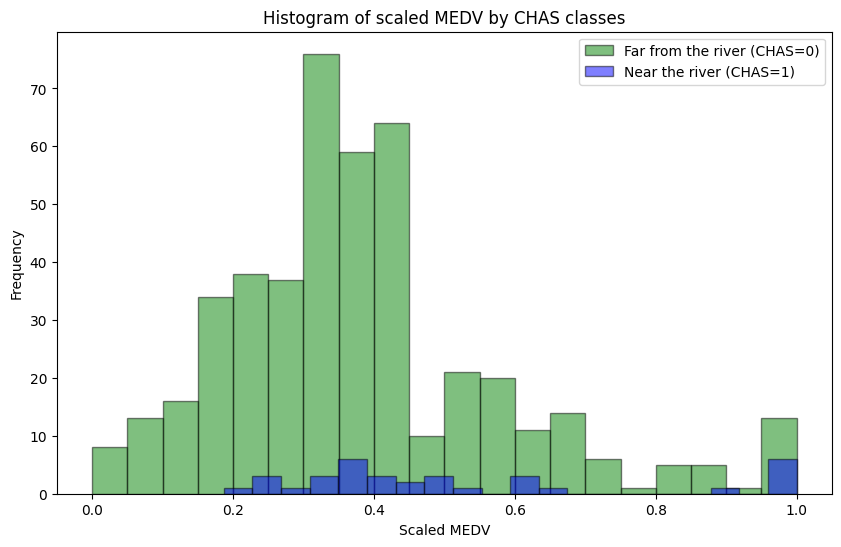

In [15]:
# HELP - SUGGESTION : AN EXAMPLE
from sklearn.preprocessing import MinMaxScaler

# Create a scaler object
scaler = MinMaxScaler()

# Adjust and transform the MEDV variable
boston['MEDV_scaled'] = scaler.fit_transform(boston[['MEDV']])

# Create a histogram plot for scaled CHAS classes
plt.figure(figsize=(10, 6))

# Filter data for each CHAS class
chas_0 = boston[boston['CHAS'] == 0]['MEDV_scaled']
chas_1 = boston[boston['CHAS'] == 1]['MEDV_scaled']

# Create superimposed histograms with legend
plt.hist(chas_0, bins=20, alpha=0.5, label='Far from the river (CHAS=0)', color='green', edgecolor='black')
plt.hist(chas_1, bins=20, alpha=0.5, label='Near the river (CHAS=1)', color='blue', edgecolor='black')
plt.xlabel('Scaled MEDV')
plt.ylabel('Frequency')
plt.legend()

plt.title('Histogram of scaled MEDV by CHAS classes')
plt.show()

### **Analysis:**

Looking at the histograms, does it seem that the CHAS attribute will have any weight when predicting the median house price, MEDV? Why?



### **Exercise:**

Repeat the previous histograms, adding a vertical line indicating the mean of each of the histograms. Paint the lines in the same color as the histogram so that it is clear which one they refer to. Add to the legend the CHAS class and the values of the mean and the standard deviation in question. The purpose is to numerically verify the differences identified previously visually.

**Hint:** You can use "axvline", from matplotlib axis, for the vertical lines.

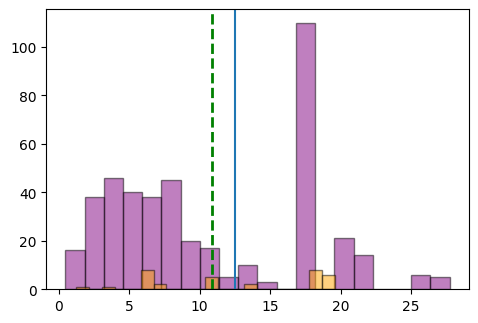

In [16]:
# HELP - SUGGESTION : YOU CAN FOLLOW THIS LINE (BUT NOT NECESSARILY)
# Create a histogram plot separated by scaled CHAS classes
plt.figure(figsize=(12, 8))

# Filter data for each CHAS class
chas_0 = boston[boston['CHAS'] == 0]
chas_1 = boston[boston['CHAS'] == 1]

# Histogram of INDUS

plt.subplot(2, 2, 1)
plt.hist(chas_0['INDUS'], bins=20, alpha=0.5, label='Near the river (CHAS=0)', color='purple', edgecolor='black')
plt.hist(chas_1['INDUS'], bins=20, alpha=0.5, label='Far from the river (CHAS=1)', color='orange', edgecolor='black')
plt.axvline(chas_0['INDUS'].mean(), color='green', linestyle='dashed', linewidth=2, label=f'Mean CHAS=0: {chas_0["INDUS"].mean():.2f}\nStandard Deviation: {chas_0["INDUS"].std():.2f}')
plt.axvline(chas_1['INDUS'].mean())

### **Exercise:**

Identify the two attributes that have the strongest correlation with the response and the 2 with the weakest correlation (correlation coefficient greater or less in absolute value). To observe and analyze the correlations graphically, represent, for each of the 4 identified attributes, a scatter plot with the attribute on the x-axis and the response on the y-axis. In addition, in each graph, add the representation of a linear regression that fits the points.

Hint: You can use the "regplot" function from the 'seaborn' library.

Fuertes: ['LSTAT', 'RM']
Débiles: ['DIS', 'B']


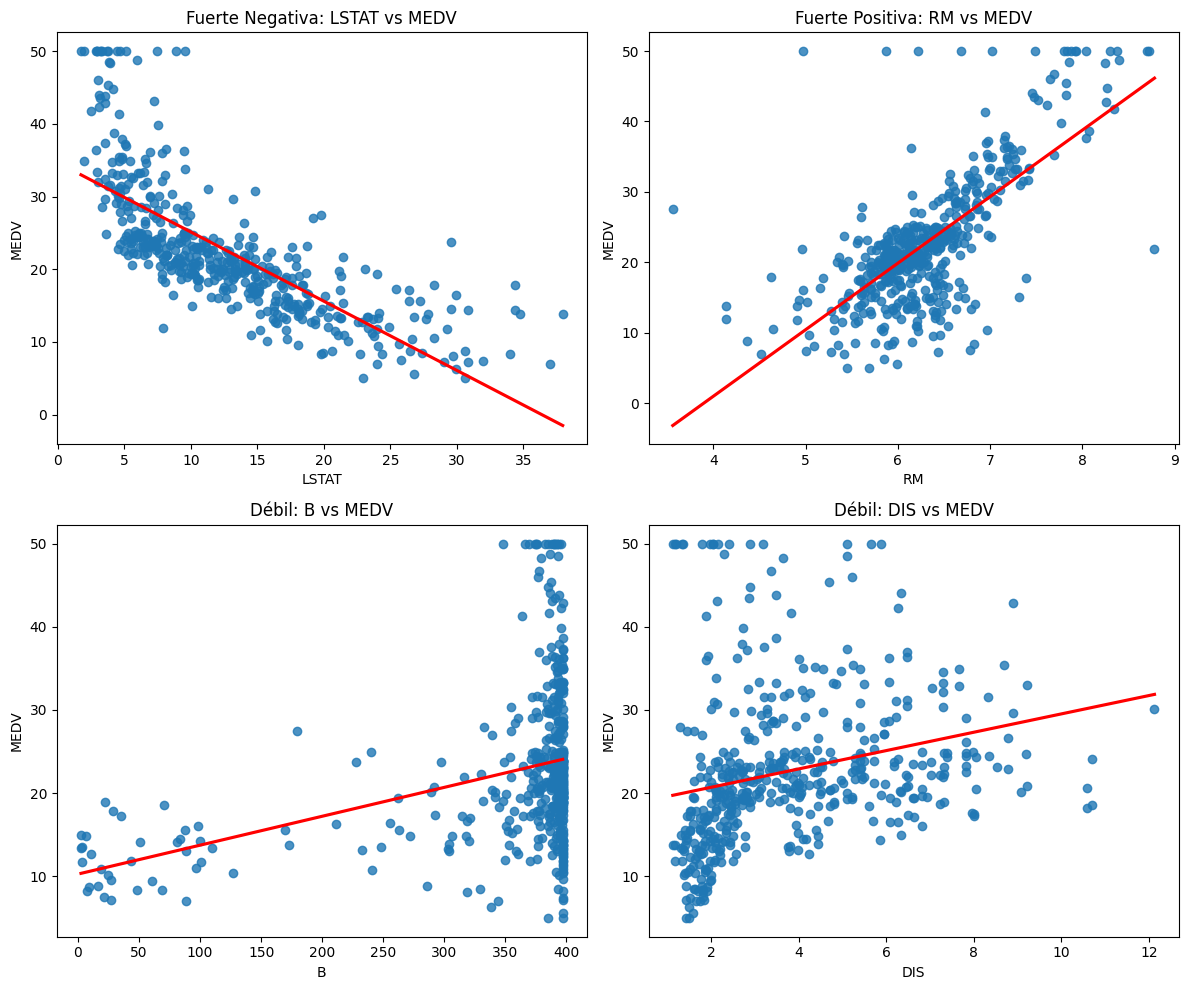

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt


correlaciones = boston[num_feats + [response]].corr()[response].drop(response)

fuertes = correlaciones.abs().nlargest(2).index.tolist()

debiles = correlaciones.abs().nsmallest(2).index.tolist()

print(f"Fuertes: {fuertes}")
print(f"Débiles: {debiles}")

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.regplot(x=df['LSTAT'], y=df['MEDV'], ci=None, line_kws={"color": "red"})
plt.title("Fuerte Negativa: LSTAT vs MEDV")

plt.subplot(2, 2, 2)
sns.regplot(x=df['RM'], y=df['MEDV'], ci=None, line_kws={"color": "red"})
plt.title("Fuerte Positiva: RM vs MEDV")

plt.subplot(2, 2, 3)
sns.regplot(x=df['B'], y=df['MEDV'], ci=None, line_kws={"color": "red"})
plt.title("Débil: B vs MEDV")

plt.subplot(2, 2, 4)
sns.regplot(x=df['DIS'], y=df['MEDV'], ci=None, line_kws={"color": "red"})
plt.title("Débil: DIS vs MEDV")

plt.tight_layout()
plt.show()

### **Analysis:**

Looking at the graphs, briefly comment on whether you can see the high or low correlations that you had identified numerically.


# Additional Notes:

Remember that the correlation is measured with a coefficient that ranges from -1 to 1. Values close to -1 or 1 indicate a strong correlation (either negative or positive), while values close to 0 indicate a weak or no correlation.

Scatter plots allow you to visualize the relationship between two variables. If the points are grouped around a straight line, this suggests a linear correlation. The slope of the line indicates the direction of the correlation (positive or negative).

Linear regression fits a straight line to the data to model the relationship between the variables. The better the points fit the line, the stronger the correlation.


I hope this helps to better understand the concept of correlation and how to visualize it.

# Additional Tips:

Correlation does not imply causation. Just because two variables are correlated, it doesn't necessarily mean that one causes the other.

Explore different types of visualizations (e.g., heatmaps) to get a more comprehensive understanding of the relationships between variables.

Always consider the context of the data and the specific problem that you are trying to solve when interpreting correlations.
